# Effect of Image Filtering on Skin-Lesion Classification
### Lab 02: Baseline vs. 5 Spatial Filters, on the Top 3 Models from Lab 01

This notebook implements Lab Activity 2 in full: it takes the **top 3 pretrained backbones identified in Lab 1's Table 1** (by test accuracy), establishes a baseline (unfiltered) experiment for each, then compares them against 5 classical spatial-domain filters, keeping the dataset split, preprocessing, training settings, and evaluation procedure identical across all 18 (3 model x 6 condition) runs so the comparison is fair.

| # | Model | Lab 1 test accuracy |
|---|---|---|
| Model 1 | **ResNet50** | 81.19% |
| Model 2 | **EfficientNet-B0** | 81.08% |
| Model 3 | **DenseNet121** | 80.95% |

These were the top 3 of the 8 backbones compared in Lab 1 (next best was ResNet101 at 80.89%, so the cut is clean). See `TOP3_MODELS` in §2 if you want to swap one out.

**Dataset note:** the brief asks for HAM10000. This notebook instead reuses the **same ISIC 2019, 5-class subset** (`MEL, NV, BCC, BKL, AK`, 24,211 images) that Lab 1 already used, per your instruction to keep continuity across the two lab tasks. This is a reasonable substitution, not a different problem: HAM10000 (10,015 images, the ISIC 2018 Task 3 training set) is the predecessor dataset that ISIC 2019 was built on top of (ISIC 2019 = HAM10000 + the BCN20000 and MSK collections + a new `SCC` class), and all 5 of the classes used here (`AK, BCC, BKL, MEL, NV`) already exist under the same names in HAM10000 too. So the class taxonomy is identical either way; only the exact image pool differs (ISIC 2019's larger collection vs. HAM10000's specific 10,015 images). If your instructor specifically wants HAM10000's exact image files rather than this superset, say so and this notebook's dataset-download cell is the only part that needs to change.

**Epoch budget:** each of the 18 runs uses **1 warmup epoch (backbone frozen, lr 1e-3) + 4 fine-tune epochs (unfrozen, lr 1e-4) = 5 epochs**, a deliberately lighter schedule than Lab 1's 2+6, chosen so the full sweep fits in roughly 3.5-4 hours instead of 5-6. What matters for this lab is that the schedule is *identical* across all 18 runs, which it is; absolute accuracy will likely run a little below Lab 1's numbers, but the baseline-vs-filter comparison this lab is actually testing is unaffected by that. Change `CONFIG["epochs_warmup"]` / `CONFIG["epochs_finetune"]` in §2 if you'd rather match Lab 1 exactly (expect ~5-6 hours).

**Crash-resilience:** given Lab 1 hit two Colab disconnects, every one of the 18 runs below is checkpointed immediately after it finishes (§4's `run_sweep` helper), and those checkpoints are saved to **your Google Drive** (`CONFIG["save_to_drive"] = True` by default) rather than the Colab VM's local disk. The difference matters: a plain disconnect-and-reconnect usually keeps the same VM (local `/content` survives), but a full crash, "Factory reset runtime", or a new session entirely gives you a brand new VM with an empty local disk, and only Drive survives that. Either way, the fix is the same: just re-run from the top (`Runtime -> Run all`, or at least §3 onward). Dataset prep and image caching redo their (cheap, ~9-minute) work since that's all in RAM, but §5/§7's `run_sweep` calls check the Drive-saved results first and skip every (model, filter) pair already completed, training only what's left. The one manual step is a one-time Google authorization popup when Drive mounts (§2), asking again after a full runtime reset is normal, just click through it. Set `CONFIG["save_to_drive"] = False` if you'd rather not grant Drive access and accept that a full reset loses all progress.

**Notebook sections** (matching what the brief asks the code to be organized into):

| Section | Contents |
|---|---|
| §2 Setup | imports, `CONFIG`, filter/model lists |
| §3 Dataset Preparation | download, 5-class filter, split, image caching (identical to Lab 1) |
| §4 Model Loading | backbone + training/eval utilities for the top 3 models |
| §5 Baseline Experiment | the 3 models, unfiltered |
| §6 Image Filtering | the 5 filters, defined and visualized on sample images |
| §7 Training | the 3 models x 5 filters = 15 filtered runs |
| §8 Evaluation | combined 18-row results table (accuracy/precision/recall/F1/macro-F1/balanced accuracy/AUC) |
| §9 Visualization | accuracy & loss curves, confusion matrices, ROC, per-class heatmap |
| §10 Comparative Analysis | baseline-vs-filter deltas, cross-model consistency, most-affected classes (feeds directly into the "Questions to Answer" section of the brief) |

Run top to bottom in Google Colab with a GPU runtime (`Runtime -> Change runtime type -> GPU`).


## 2. Setup

In [1]:
# Packages not preinstalled on Colab (safe to re-run)
!pip install -q kagglehub --upgrade


In [2]:
import os, glob, time, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
RESAMPLE_BILINEAR = getattr(getattr(Image, "Resampling", Image), "BILINEAR")  # Pillow-version-safe

try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
    import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    balanced_accuracy_score, confusion_matrix,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CONFIG = {
    "seed": SEED,
    "img_size": 224,
    "batch_size": 64,
    "num_workers": min(4, os.cpu_count() or 2),
    "selected_classes": ["MEL", "NV", "BCC", "BKL", "AK"],  # same 5 classes as Lab 1
    "epochs_warmup": 1,     # phase 1: backbone frozen, train only the new head
    "epochs_finetune": 4,   # phase 2: backbone unfrozen, fine-tune the whole network
    "lr_warmup": 1e-3,
    "lr_finetune": 1e-4,
    "val_size": 0.15,
    "test_size": 0.15,
    "cache_images_in_ram": True,
    "save_to_drive": True,  # <-- persist checkpoints in Google Drive so a full runtime reset can resume, not just a soft disconnect
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
print("Using device:", CONFIG["device"])
if CONFIG["device"] == "cpu":
    print("WARNING: no GPU detected. 18 training runs on CPU will be extremely slow, "
          "in Colab go to Runtime > Change runtime type > GPU.")

TOP3_MODELS = ["resnet50", "efficientnet_b0", "densenet121"]  # ranked by Lab 1 Table 1 accuracy
MODEL_DISPLAY = {"resnet50": "ResNet50", "efficientnet_b0": "EfficientNet-B0", "densenet121": "DenseNet121"}

FILTERS = ["none", "average", "gaussian", "median", "sharpen", "sobel"]
FILTER_DISPLAY = {
    "none": "No Filter", "average": "Average", "gaussian": "Gaussian",
    "median": "Median", "sharpen": "Sharpening", "sobel": "Sobel",
}

# Checkpoints (RESULTS_CSV/EXTRAS_JSON) live on Google Drive by default, so §5/§7's run_sweep
# can resume after a FULL runtime reset (new VM, empty local disk), not just a soft disconnect
# on the same VM. The first mount on a fresh runtime pops a one-time Google auth prompt in the
# UI -- click through it (this is your own Drive; nothing is shared or uploaded anywhere else).
RESULTS_DIR = "/content/lab02_results"  # local fallback if Drive isn't used/available
if CONFIG["save_to_drive"]:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        RESULTS_DIR = "/content/drive/MyDrive/Lab02_ISIC_Filters"
    except ImportError:
        print("google.colab not available (not running in Colab?) -- falling back to local, "
              "non-persistent storage. A full runtime reset will lose all progress.")
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_CSV = f"{RESULTS_DIR}/results.csv"
EXTRAS_JSON = f"{RESULTS_DIR}/extras.json"
persisted = RESULTS_DIR.startswith("/content/drive/")
print("Checkpointing to:", RESULTS_DIR, "(Drive: survives a full runtime reset)" if persisted
      else "(LOCAL ONLY: a full runtime reset will lose all completed runs)")

CONFIG


Using device: cuda
Mounted at /content/drive
Checkpointing to: /content/drive/MyDrive/Lab02_ISIC_Filters (Drive: survives a full runtime reset)


{'seed': 42,
 'img_size': 224,
 'batch_size': 64,
 'num_workers': 2,
 'selected_classes': ['MEL', 'NV', 'BCC', 'BKL', 'AK'],
 'epochs_warmup': 1,
 'epochs_finetune': 4,
 'lr_warmup': 0.001,
 'lr_finetune': 0.0001,
 'val_size': 0.15,
 'test_size': 0.15,
 'cache_images_in_ram': True,
 'save_to_drive': True,
 'device': 'cuda'}

## 3. Dataset Preparation

Same dataset, same 5-class filter, same stratified 70/15/15 split (same seed) and same in-RAM image caching as Lab 1, so the two labs' results stay comparable. See the title cell above for why ISIC 2019 is used here in place of HAM10000.


In [3]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("salviohexia/isic-2019-skin-lesion-images-for-classification")
print("Path to dataset files:", DATA_DIR)

print("\nTop-level contents of", DATA_DIR)
for root, dirs, fnames in os.walk(DATA_DIR):
    depth = root[len(DATA_DIR):].count(os.sep)
    if depth <= 1:
        print(root, "->", dirs[:10], f"(+{len(fnames)} files)" if fnames else "")


100%|██████████| 9.10G/9.10G [07:56<00:00, 20.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1

Top-level contents of /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1 -> ['DF', 'AK', 'VASC', 'SCC', 'BKL', 'NV', 'BCC', 'MEL'] (+2 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/DF -> [] (+239 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/AK -> [] (+867 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/VASC -> [] (+253 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/SCC -> [] (+628 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-

In [4]:
# Auto-detect the ground-truth CSV and index every image by filename (this dataset
# stores images inside per-class subfolders, not one flat folder).
csv_candidates = [p for p in glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
                   if "ground" in p.lower() or "groundtruth" in p.lower()]
print("Ground-truth CSV candidates found:", csv_candidates)
GT_CSV_PATH = csv_candidates[0] if csv_candidates else None  # <-- SET MANUALLY IF WRONG

image_paths = (
    glob.glob(f"{DATA_DIR}/**/*.jpg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.jpeg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.png", recursive=True)
)
image_folders = sorted({os.path.dirname(p) for p in image_paths})
IMAGE_INDEX = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}

print(f"Indexed {len(IMAGE_INDEX)} images across {len(image_folders)} folder(s):")
for f in image_folders:
    print(" ", f, f"({len(glob.glob(f'{f}/*.*'))} files)")

print("\nUsing GT_CSV_PATH =", GT_CSV_PATH)
assert GT_CSV_PATH, "Could not auto-detect the ground-truth CSV (set GT_CSV_PATH manually above)."
assert len(IMAGE_INDEX) > 0, "Could not find any images under DATA_DIR (check the download)."


Ground-truth CSV candidates found: ['/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/ISIC_2019_Training_GroundTruth.csv']
Indexed 25331 images across 8 folder(s):
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/AK (867 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BCC (3323 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BKL (2624 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/DF (239 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/MEL (4522 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/NV (12875 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-201

Filtered to ['MEL', 'NV', 'BCC', 'BKL', 'AK'] -> kept 24211/25331 images

Class distribution:
label
NV     12875
MEL     4522
BCC     3323
BKL     2624
AK       867
Name: count, dtype: int64

Classes: ['AK', 'BCC', 'BKL', 'MEL', 'NV']  | NUM_CLASSES = 5


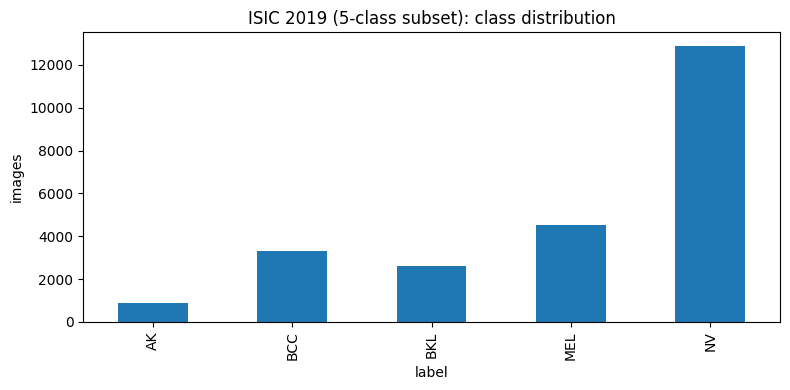

In [5]:
gt = pd.read_csv(GT_CSV_PATH)
class_cols = [c for c in gt.columns if c.lower() != "image"]
if "UNK" in gt.columns and gt["UNK"].sum() == 0:
    class_cols = [c for c in class_cols if c != "UNK"]

gt["label"] = gt[class_cols].idxmax(axis=1)
gt["filepath"] = gt["image"].map(IMAGE_INDEX)

n_missing = gt["filepath"].isna().sum()
if n_missing:
    print(f"Warning: {n_missing} images listed in the CSV were not found on disk, dropping them.")
gt = gt.dropna(subset=["filepath"]).reset_index(drop=True)

before = len(gt)
gt = gt[gt["label"].isin(CONFIG["selected_classes"])].reset_index(drop=True)
print(f"Filtered to {CONFIG['selected_classes']} -> kept {len(gt)}/{before} images")

print("\nClass distribution:")
print(gt["label"].value_counts())

CLASSES = sorted(gt["label"].unique().tolist())
label2idx = {c: i for i, c in enumerate(CLASSES)}
gt["label_idx"] = gt["label"].map(label2idx)
NUM_CLASSES = len(CLASSES)
print("\nClasses:", CLASSES, " | NUM_CLASSES =", NUM_CLASSES)

ax = gt["label"].value_counts().reindex(CLASSES).plot(kind="bar", figsize=(8, 4), title="ISIC 2019 (5-class subset): class distribution")
ax.set_ylabel("images"); plt.tight_layout(); plt.show()


In [6]:
train_df, temp_df = train_test_split(
    gt, test_size=CONFIG["val_size"] + CONFIG["test_size"],
    stratify=gt["label_idx"], random_state=CONFIG["seed"]
)
val_fraction_of_temp = CONFIG["val_size"] / (CONFIG["val_size"] + CONFIG["test_size"])
val_df, test_df = train_test_split(
    temp_df, train_size=val_fraction_of_temp,
    stratify=temp_df["label_idx"], random_state=CONFIG["seed"]
)
train_df, val_df, test_df = (d.reset_index(drop=True) for d in (train_df, val_df, test_df))
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")


train=16947  val=3632  test=3632


In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Cache the RESIZED, UNFILTERED pixel arrays once (same fix as Lab 1). Filters are then
# applied on the fly per-item in FilteredISICDataset (§4): they're cheap (sub-millisecond
# per image with OpenCV) compared to the JPEG decode/resize this cache already eliminates,
# and this avoids caching 6 filtered copies of the dataset (~6x the RAM) simultaneously.
IMAGE_CACHE = {}
if CONFIG["cache_images_in_ram"]:
    def load_resized(path, size):
        with Image.open(path) as im:
            return np.asarray(im.convert("RGB").resize((size, size), RESAMPLE_BILINEAR), dtype=np.uint8)

    used_paths = pd.concat([train_df, val_df, test_df])["filepath"].unique()
    est_gb = len(used_paths) * (CONFIG["img_size"] ** 2) * 3 / 1e9
    print(f"Caching {len(used_paths)} images at {CONFIG['img_size']}x{CONFIG['img_size']} (~{est_gb:.2f} GB in RAM)...")
    t0 = time.time()
    for i, p in enumerate(used_paths):
        IMAGE_CACHE[p] = load_resized(p, CONFIG["img_size"])
        if (i + 1) % 5000 == 0:
            print(f"  cached {i+1}/{len(used_paths)}  ({(time.time()-t0)/60:.1f} min elapsed)")
    print(f"Done caching {len(IMAGE_CACHE)} images in {(time.time()-t0)/60:.1f} min.")

class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_df["label_idx"].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(CONFIG["device"])
print("Class weights:", dict(zip(CLASSES, class_weights.round(2))))


Caching 24211 images at 224x224 (~3.64 GB in RAM)...
  cached 5000/24211  (1.4 min elapsed)
  cached 10000/24211  (2.8 min elapsed)
  cached 15000/24211  (4.2 min elapsed)
  cached 20000/24211  (5.6 min elapsed)
Done caching 24211 images in 6.8 min.
Class weights: {'AK': np.float64(5.58), 'BCC': np.float64(1.46), 'BKL': np.float64(1.85), 'MEL': np.float64(1.07), 'NV': np.float64(0.38)}


## 4. Model Loading

Only the 3 winning backbones from Lab 1. Same head-replacement pattern as Lab 1: swap the final classification layer for a fresh 5-class `Linear` layer.


In [8]:
def get_head_module(model, name):
    if name == "resnet50":
        return model.fc
    if name == "densenet121":
        return model.classifier
    if name == "efficientnet_b0":
        return model.classifier[1]
    raise ValueError(name)

def build_model(name, num_classes, freeze_backbone=True):
    if name == "resnet50":
        model = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = tvm.densenet121(weights=tvm.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        model = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model name: {name}")

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
        for p in get_head_module(model, name).parameters():
            p.requires_grad = True
    return model


### Training & evaluation utilities

Shared by both §5 (Baseline) and §7 (Training): the same 2-phase warmup/fine-tune loop (now returning per-epoch history for the curves in §9), the same evaluation routine (now also returning the confusion matrix, per-class metrics, and balanced accuracy needed by §8-§10), and a small checkpoint helper so a condition already recorded in `RESULTS_CSV` is skipped on re-run rather than retrained.


In [9]:
def train_one_phase(model, train_loader, val_loader, epochs, lr, class_weights, device, phase_label=""):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    tag = f"[{phase_label}] " if phase_label else ""
    history = {"phase": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct_tr, n_tr = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct_tr += (outputs.argmax(1) == labels).sum().item()
            n_tr += imgs.size(0)
        train_loss, train_acc = running_loss / n_tr, correct_tr / n_tr

        model.eval()
        val_loss, correct_val, n_val = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                correct_val += (outputs.argmax(1) == labels).sum().item()
                n_val += imgs.size(0)
        val_loss, val_acc = val_loss / n_val, correct_val / n_val

        history["phase"].append(phase_label)
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        print(f"  {tag}epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    return model, history

def train_warmup_finetune(model, train_loader, val_loader, config, class_weights, device):
    full_history = {"phase": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    if config["epochs_warmup"] > 0:
        model, h = train_one_phase(model, train_loader, val_loader, config["epochs_warmup"],
                                    config["lr_warmup"], class_weights, device, phase_label="warmup")
        for k in full_history: full_history[k].extend(h[k])
    if config["epochs_finetune"] > 0:
        for p in model.parameters():
            p.requires_grad = True
        model, h = train_one_phase(model, train_loader, val_loader, config["epochs_finetune"],
                                    config["lr_finetune"], class_weights, device, phase_label="finetune")
        for k in full_history: full_history[k].extend(h[k])
    return model, full_history

def evaluate_full(model, loader, num_classes, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            probs = torch.softmax(model(imgs), dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

    acc = (all_preds == all_labels).mean()
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro", labels=np.arange(num_classes))
    except ValueError:
        auc = float("nan")

    pc_p, pc_r, pc_f1, pc_support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0, labels=np.arange(num_classes))
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    summary = {
        "Accuracy (%)": acc * 100, "Precision (%)": precision * 100, "Recall (%)": recall * 100,
        "F1-score (%)": f1 * 100, "Macro-F1 (%)": f1 * 100,  # same quantity, reported under both
        # names because the brief's table lists them as separate columns
        "Balanced Accuracy (%)": bal_acc * 100, "AUC (%)": auc * 100,
    }
    per_class = {"precision": pc_p.tolist(), "recall": pc_r.tolist(), "f1": pc_f1.tolist(), "support": pc_support.tolist()}
    return summary, per_class, cm.tolist(), all_labels.tolist(), all_probs.tolist()

def load_checkpoint():
    completed = set()
    if os.path.exists(RESULTS_CSV):
        prev = pd.read_csv(RESULTS_CSV)
        completed = set(zip(prev["Model"], prev["Filter"]))
    extras = {}
    if os.path.exists(EXTRAS_JSON):
        with open(EXTRAS_JSON) as f:
            extras = json.load(f)
    return completed, extras

def save_condition(row, key, extras, extra_payload):
    pd.DataFrame([row]).to_csv(RESULTS_CSV, mode="a", header=not os.path.exists(RESULTS_CSV), index=False)
    extras[key] = extra_payload
    with open(EXTRAS_JSON, "w") as f:
        json.dump(extras, f)


## 5. Baseline Experiment

Establishes the reference point before any filtering is introduced: each of the 3 models trained and evaluated on the plain, unfiltered images (`filter="none"`), using the exact dataset split and training settings that every filtered run in §7 will also use. This is what the `"No Filter"` row of every model in the final results table (§8) comes from.


In [10]:
class FilteredISICDataset(Dataset):
    '''Reads from the shared IMAGE_CACHE (§3), applies `filter_name` (identity when
    "none"), then the usual torchvision transform. Defined here (ahead of §6) because
    the baseline run below needs it too: §6 defines what apply_filter actually does
    for the 5 real filters; here it's just the "none" branch, i.e. an identity op.'''
    def __init__(self, df, filter_name, transform=None):
        self.df = df.reset_index(drop=True)
        self.filter_name = filter_name
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = IMAGE_CACHE[row["filepath"]]
        arr = apply_filter(arr, self.filter_name)
        img = Image.fromarray(arr)
        if self.transform:
            img = self.transform(img)
        return img, int(row["label_idx"])

def apply_filter(img_uint8, filter_name):
    if filter_name == "none":
        return img_uint8
    return _apply_real_filter(img_uint8, filter_name)  # implemented in §6; placeholder until then

# No augmentation at eval time; train gets a horizontal flip + small rotation, same as Lab 1.
train_transform = T.Compose([T.RandomHorizontalFlip(), T.RandomRotation(15), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
eval_transform = T.Compose([T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

def build_filtered_loaders(filter_name):
    _persist = CONFIG["num_workers"] > 0
    train_ds = FilteredISICDataset(train_df, filter_name, train_transform)
    val_ds = FilteredISICDataset(val_df, filter_name, eval_transform)
    test_ds = FilteredISICDataset(test_df, filter_name, eval_transform)
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                              num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
    return train_loader, val_loader, test_loader

def run_sweep(filters_to_run, models_to_run):
    '''Trains+evaluates every (model, filter) pair not already in RESULTS_CSV, checkpointing
    after each one. Re-running this with the same arguments after a disconnect resumes
    rather than redoing completed work.'''
    completed, extras = load_checkpoint()
    for filt in filters_to_run:
        train_loader, val_loader, test_loader = build_filtered_loaders(filt)
        for name in models_to_run:
            disp_model, disp_filter = MODEL_DISPLAY[name], FILTER_DISPLAY[filt]
            if (disp_model, disp_filter) in completed:
                print(f"Skipping {disp_model} / {disp_filter} (already completed)")
                continue

            print(f"\n=== {disp_model}  |  filter={disp_filter} ===")
            t0 = time.time()
            model = build_model(name, NUM_CLASSES, freeze_backbone=True)
            model, history = train_warmup_finetune(model, train_loader, val_loader, CONFIG, class_weights_tensor, CONFIG["device"])
            summary, per_class, cm, y_true, y_prob = evaluate_full(model, test_loader, NUM_CLASSES, CONFIG["device"])
            elapsed = time.time() - t0

            row = {"Model": disp_model, "Filter": disp_filter, **summary, "Train Time (s)": round(elapsed, 1)}
            print(f"{disp_model} / {disp_filter}: acc={summary['Accuracy (%)']:.2f}%  (took {elapsed/60:.1f} min)")

            payload = {"history": history, "confusion_matrix": cm, "per_class": per_class}
            if filt == "none":  # only keep raw predictions for the baseline (used by §9's ROC plot), keeps the checkpoint file small
                payload["y_true"], payload["y_prob"] = y_true, y_prob
            save_condition(row, f"{name}__{filt}", extras, payload)
            completed.add((disp_model, disp_filter))

            del model
            if CONFIG["device"] == "cuda":
                torch.cuda.empty_cache()

# --- run the baseline (filter="none") for all 3 models ---
run_sweep(filters_to_run=["none"], models_to_run=TOP3_MODELS)


Skipping ResNet50 / No Filter (already completed)
Skipping EfficientNet-B0 / No Filter (already completed)
Skipping DenseNet121 / No Filter (already completed)


## 6. Image Filtering

Five spatial-domain filters, implemented with OpenCV and applied to the already-resized 224x224 RGB arrays from the cache (so filtering cost is paid once per image per epoch, not on top of the decode/resize Lab 1 already fixed):

- **Average / Mean** (`cv2.blur`, 5x5): replaces each pixel with the mean of its 5x5 neighbourhood, smoothing noise but also blurring edges.
- **Gaussian** (`cv2.GaussianBlur`, 5x5): a weighted version of the same idea, weighting nearby pixels more (smoother, less "blocky" than the mean filter).
- **Median** (`cv2.medianBlur`, 5x5): replaces each pixel with the neighbourhood median, smoothing while preserving edges better than mean/Gaussian, since it doesn't average across an edge.
- **Sharpening** (`cv2.filter2D` with kernel `[[0,-1,0],[-1,5,-1],[0,-1,0]]`): boosts local contrast by subtracting a blurred version of the neighbourhood from the center pixel (the opposite goal of the three filters above).
- **Sobel edge** (`cv2.Sobel`, converted to grayscale first, gradient magnitude from the x- and y-direction kernels, then replicated back to 3 channels): keeps only intensity *transitions* and discards flat regions entirely, the most aggressive transformation of the five.

The first four are applied directly to all 3 RGB channels; Sobel is computed on grayscale (the conventional way to do edge detection) and the resulting single-channel edge map is replicated across 3 channels so it still fits the same 3-channel model input pipeline.


In [11]:
def _apply_real_filter(img_uint8, filter_name):
    if filter_name == "average":
        return cv2.blur(img_uint8, (5, 5))
    if filter_name == "gaussian":
        return cv2.GaussianBlur(img_uint8, (5, 5), 0)
    if filter_name == "median":
        return cv2.medianBlur(img_uint8, 5)
    if filter_name == "sharpen":
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
        return cv2.filter2D(img_uint8, -1, kernel)
    if filter_name == "sobel":
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(gx ** 2 + gy ** 2)
        mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)
    raise ValueError(filter_name)

# quick correctness check now that _apply_real_filter exists
_sample_path = train_df.iloc[0]["filepath"]
_sample_arr = IMAGE_CACHE[_sample_path]
for f in FILTERS[1:]:
    out = apply_filter(_sample_arr, f)
    assert out.shape == _sample_arr.shape and out.dtype == np.uint8, f"filter {f} changed shape/dtype unexpectedly"
print("All 5 filters produce a", _sample_arr.shape, _sample_arr.dtype, "array, same as the unfiltered input. OK.")


All 5 filters produce a (224, 224, 3) uint8 array, same as the unfiltered input. OK.


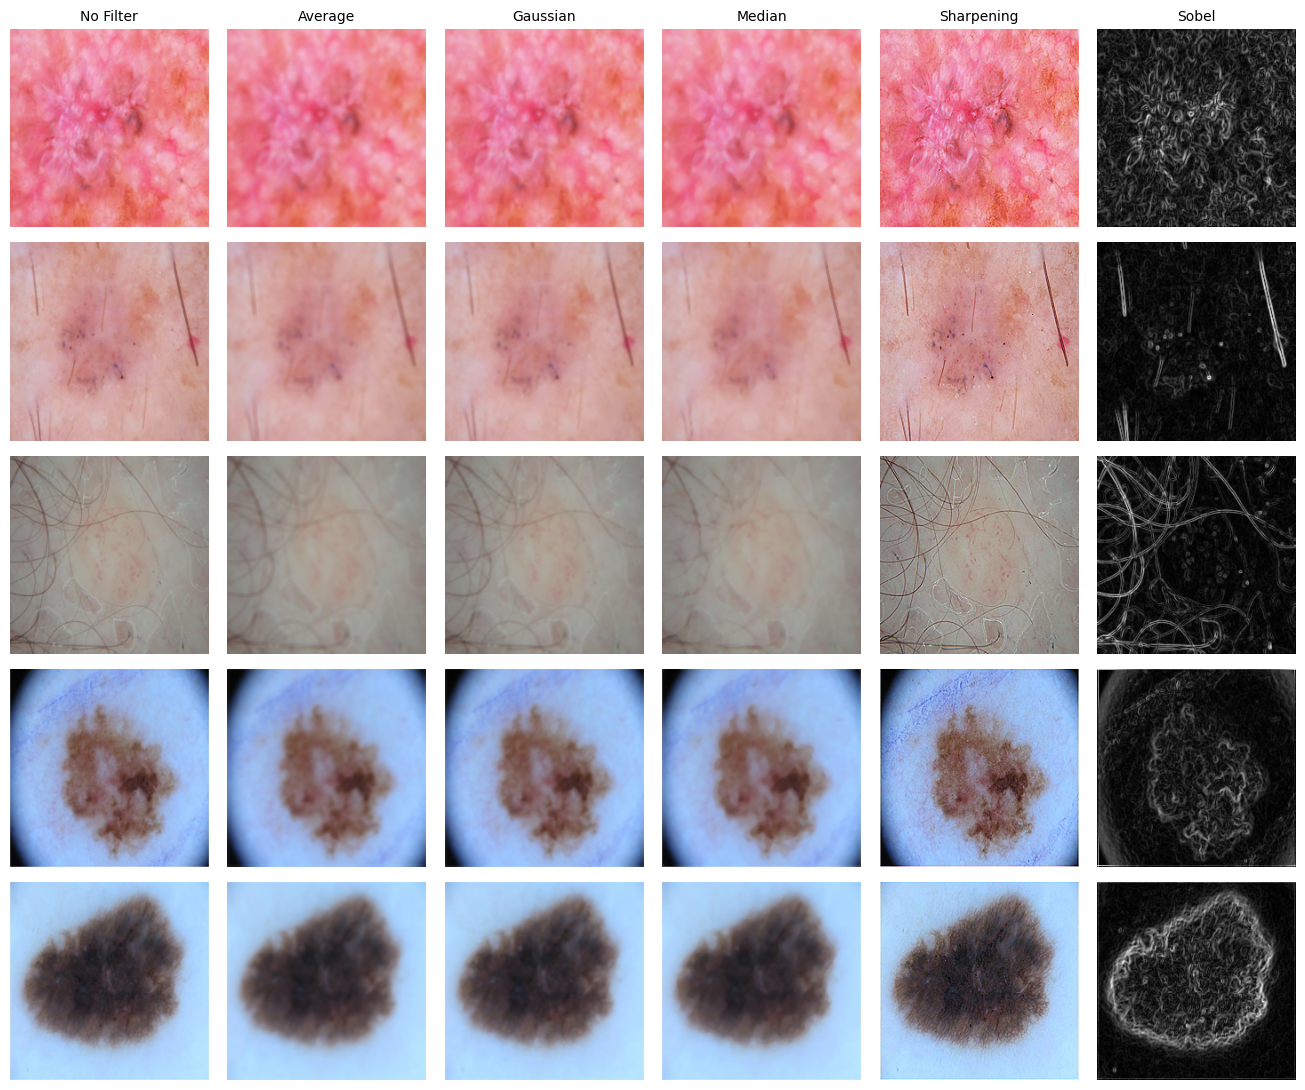

In [12]:
# Visualize one example image per class, across all 6 conditions ("Original and filtered image examples")
example_rows = gt.groupby("label").first().reindex(CLASSES)

fig, axes = plt.subplots(len(CLASSES), len(FILTERS), figsize=(2.2 * len(FILTERS), 2.2 * len(CLASSES)))
for i, (cls, row) in enumerate(example_rows.iterrows()):
    arr = IMAGE_CACHE[row["filepath"]] if row["filepath"] in IMAGE_CACHE else \
          np.asarray(Image.open(row["filepath"]).convert("RGB").resize((CONFIG["img_size"], CONFIG["img_size"]), RESAMPLE_BILINEAR))
    for j, filt in enumerate(FILTERS):
        ax = axes[i, j]
        ax.imshow(apply_filter(arr, filt))
        ax.axis("off")
        if i == 0:
            ax.set_title(FILTER_DISPLAY[filt], fontsize=10)
        if j == 0:
            ax.set_ylabel(cls, fontsize=10)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/filter_examples.png", dpi=120)
plt.show()


## 7. Training

The remaining 15 conditions: 3 models x 5 filters (`average`, `gaussian`, `median`, `sharpen`, `sobel`), using the exact same `run_sweep` helper, dataset split, and training settings as the baseline in §5. This is the cell most likely to hit a Colab disconnect given the runtime involved: re-running it is safe, already-completed conditions are skipped (see §4's `load_checkpoint`/`save_condition`).


In [13]:
run_sweep(filters_to_run=["average", "gaussian", "median", "sharpen", "sobel"], models_to_run=TOP3_MODELS)
print("\nAll conditions attempted. If any were skipped due to an error, re-run this cell.")


Skipping ResNet50 / Average (already completed)
Skipping EfficientNet-B0 / Average (already completed)
Skipping DenseNet121 / Average (already completed)
Skipping ResNet50 / Gaussian (already completed)
Skipping EfficientNet-B0 / Gaussian (already completed)
Skipping DenseNet121 / Gaussian (already completed)
Skipping ResNet50 / Median (already completed)
Skipping EfficientNet-B0 / Median (already completed)
Skipping DenseNet121 / Median (already completed)
Skipping ResNet50 / Sharpening (already completed)
Skipping EfficientNet-B0 / Sharpening (already completed)
Skipping DenseNet121 / Sharpening (already completed)

=== ResNet50  |  filter=Sobel ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s]


  [warmup] epoch 1/1  train_loss=1.4268  train_acc=0.4774  val_loss=1.3372  val_acc=0.4708
  [finetune] epoch 1/4  train_loss=1.1869  train_acc=0.5725  val_loss=1.1088  val_acc=0.6173
  [finetune] epoch 2/4  train_loss=1.0163  train_acc=0.6308  val_loss=1.0704  val_acc=0.6531
  [finetune] epoch 3/4  train_loss=0.9021  train_acc=0.6723  val_loss=1.0366  val_acc=0.6346
  [finetune] epoch 4/4  train_loss=0.7973  train_acc=0.7001  val_loss=0.9692  val_acc=0.6605
ResNet50 / Sobel: acc=67.51%  (took 13.6 min)

=== EfficientNet-B0  |  filter=Sobel ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 174MB/s]


  [warmup] epoch 1/1  train_loss=1.3999  train_acc=0.4899  val_loss=1.3113  val_acc=0.4992
  [finetune] epoch 1/4  train_loss=1.2062  train_acc=0.5632  val_loss=1.1082  val_acc=0.5909
  [finetune] epoch 2/4  train_loss=1.0321  train_acc=0.6259  val_loss=1.0124  val_acc=0.6399
  [finetune] epoch 3/4  train_loss=0.9408  train_acc=0.6564  val_loss=0.9841  val_acc=0.6938
  [finetune] epoch 4/4  train_loss=0.8330  train_acc=0.6906  val_loss=0.9441  val_acc=0.6589
EfficientNet-B0 / Sobel: acc=67.35%  (took 7.2 min)

=== DenseNet121  |  filter=Sobel ===
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 204MB/s]


  [warmup] epoch 1/1  train_loss=1.4356  train_acc=0.4614  val_loss=1.3692  val_acc=0.5308
  [finetune] epoch 1/4  train_loss=1.1727  train_acc=0.5757  val_loss=1.0484  val_acc=0.6536
  [finetune] epoch 2/4  train_loss=0.9843  train_acc=0.6464  val_loss=1.0223  val_acc=0.5876
  [finetune] epoch 3/4  train_loss=0.8677  train_acc=0.6817  val_loss=0.9843  val_acc=0.6792
  [finetune] epoch 4/4  train_loss=0.7470  train_acc=0.7178  val_loss=0.9652  val_acc=0.6302
DenseNet121 / Sobel: acc=63.99%  (took 13.6 min)

All conditions attempted. If any were skipped due to an error, re-run this cell.


## 8. Evaluation

Combines the baseline (§5) and filtered (§7) runs into the single comparison table the brief asks for, extended with a `Balanced Accuracy` column (average per-class recall, which the "Additional Analysis" section asks for explicitly even though the brief's example table doesn't have a column for it). `Macro-F1` and `F1-score` are the same macro-averaged quantity, reported under both names since the brief's table lists them as separate columns.


In [14]:
results_df = pd.read_csv(RESULTS_CSV)
results_df["Filter"] = pd.Categorical(results_df["Filter"], categories=[FILTER_DISPLAY[f] for f in FILTERS], ordered=True)
results_df["Model"] = pd.Categorical(results_df["Model"], categories=[MODEL_DISPLAY[m] for m in TOP3_MODELS], ordered=True)
results_df = results_df.sort_values(["Model", "Filter"]).reset_index(drop=True)

expected_rows = len(TOP3_MODELS) * len(FILTERS)
print(f"{len(results_df)}/{expected_rows} conditions completed.")
if len(results_df) < expected_rows:
    print("Some conditions are still missing, re-run §5/§7 until this says 18/18 before trusting the analysis below.")

cols = ["Model", "Filter", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)",
        "Macro-F1 (%)", "Balanced Accuracy (%)", "AUC (%)", "Train Time (s)"]
results_df = results_df[cols].round(2)
results_df.to_csv(f"{RESULTS_DIR}/table_filter_comparison.csv", index=False)
results_df


18/18 conditions completed.


,Model,Filter,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%),Train Time (s)
0,ResNet50,No Filter,79.57,70.25,75.18,72.35,72.35,75.18,94.77,826.2
1,ResNet50,Average,74.94,64.89,72.93,67.88,67.88,72.93,93.95,832.0
2,ResNet50,Gaussian,76.27,66.75,75.93,70.07,70.07,75.93,94.58,834.2
3,ResNet50,Median,77.42,69.27,73.28,70.95,70.95,73.28,94.56,841.8
4,ResNet50,Sharpening,80.04,71.40,77.07,73.66,73.66,77.07,95.40,832.8
5,ResNet50,Sobel,67.51,55.93,62.31,57.71,57.71,62.31,89.13,818.1
6,EfficientNet-B0,No Filter,76.38,66.90,75.80,70.09,70.09,75.80,94.55,409.7
7,EfficientNet-B0,Average,75.72,64.92,71.00,67.23,67.23,71.00,93.08,408.9
8,EfficientNet-B0,Gaussian,75.96,65.72,73.64,68.60,68.60,73.64,93.57,430.6
9,EfficientNet-B0,Median,72.96,62.74,71.33,65.48,65.48,71.33,93.00,443.6


## 9. Visualization

Training/validation curves, confusion matrices, and ROC, all organized as one grid per model so all 6 filter conditions are visible side by side.


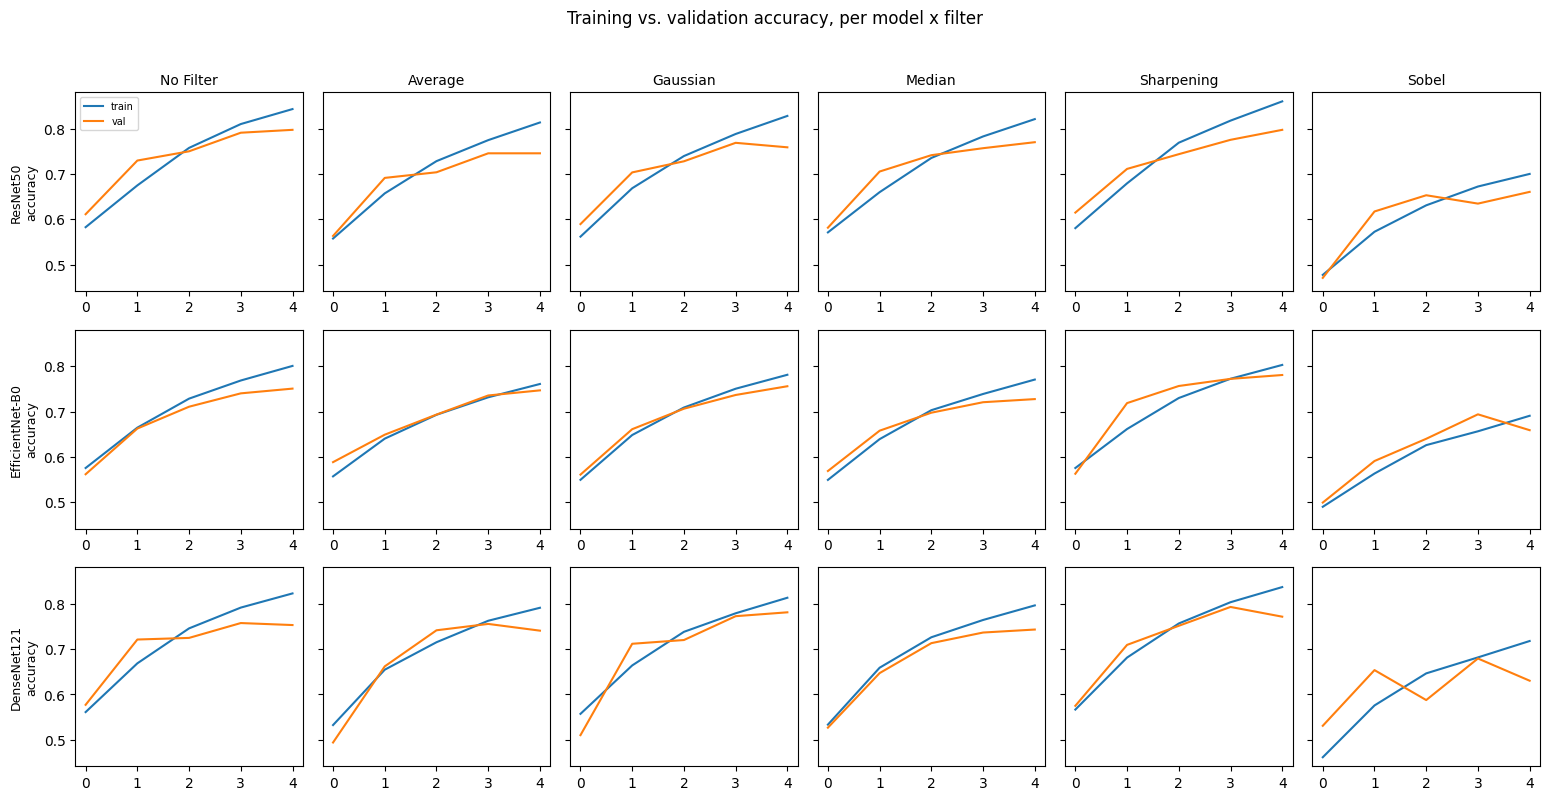

In [15]:
with open(EXTRAS_JSON) as f:
    extras = json.load(f)

def get_extra(model_name, filter_name):
    return extras.get(f"{model_name}__{filter_name}")

fig, axes = plt.subplots(len(TOP3_MODELS), len(FILTERS), figsize=(2.6 * len(FILTERS), 2.6 * len(TOP3_MODELS)), sharey=True)
for i, name in enumerate(TOP3_MODELS):
    for j, filt in enumerate(FILTERS):
        ax = axes[i, j]
        e = get_extra(name, filt)
        if e is None:
            ax.axis("off"); continue
        h = e["history"]
        ax.plot(h["train_acc"], label="train")
        ax.plot(h["val_acc"], label="val")
        if i == 0:
            ax.set_title(FILTER_DISPLAY[filt], fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{MODEL_DISPLAY[name]}\naccuracy", fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
fig.suptitle("Training vs. validation accuracy, per model x filter", y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_curves.png", dpi=120, bbox_inches="tight")
plt.show()


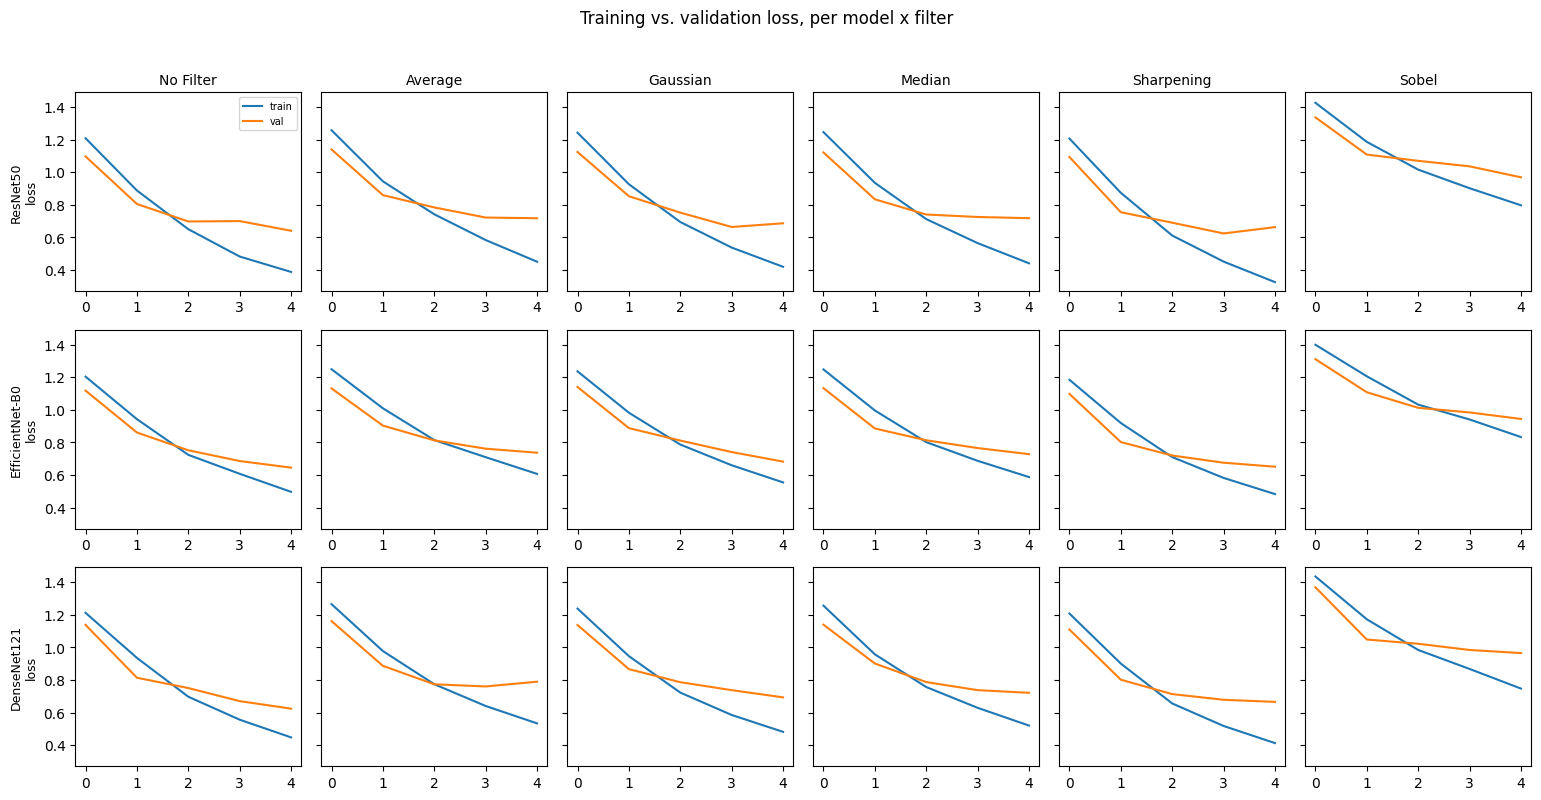

In [16]:
fig, axes = plt.subplots(len(TOP3_MODELS), len(FILTERS), figsize=(2.6 * len(FILTERS), 2.6 * len(TOP3_MODELS)), sharey=True)
for i, name in enumerate(TOP3_MODELS):
    for j, filt in enumerate(FILTERS):
        ax = axes[i, j]
        e = get_extra(name, filt)
        if e is None:
            ax.axis("off"); continue
        h = e["history"]
        ax.plot(h["train_loss"], label="train")
        ax.plot(h["val_loss"], label="val")
        if i == 0:
            ax.set_title(FILTER_DISPLAY[filt], fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{MODEL_DISPLAY[name]}\nloss", fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
fig.suptitle("Training vs. validation loss, per model x filter", y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()


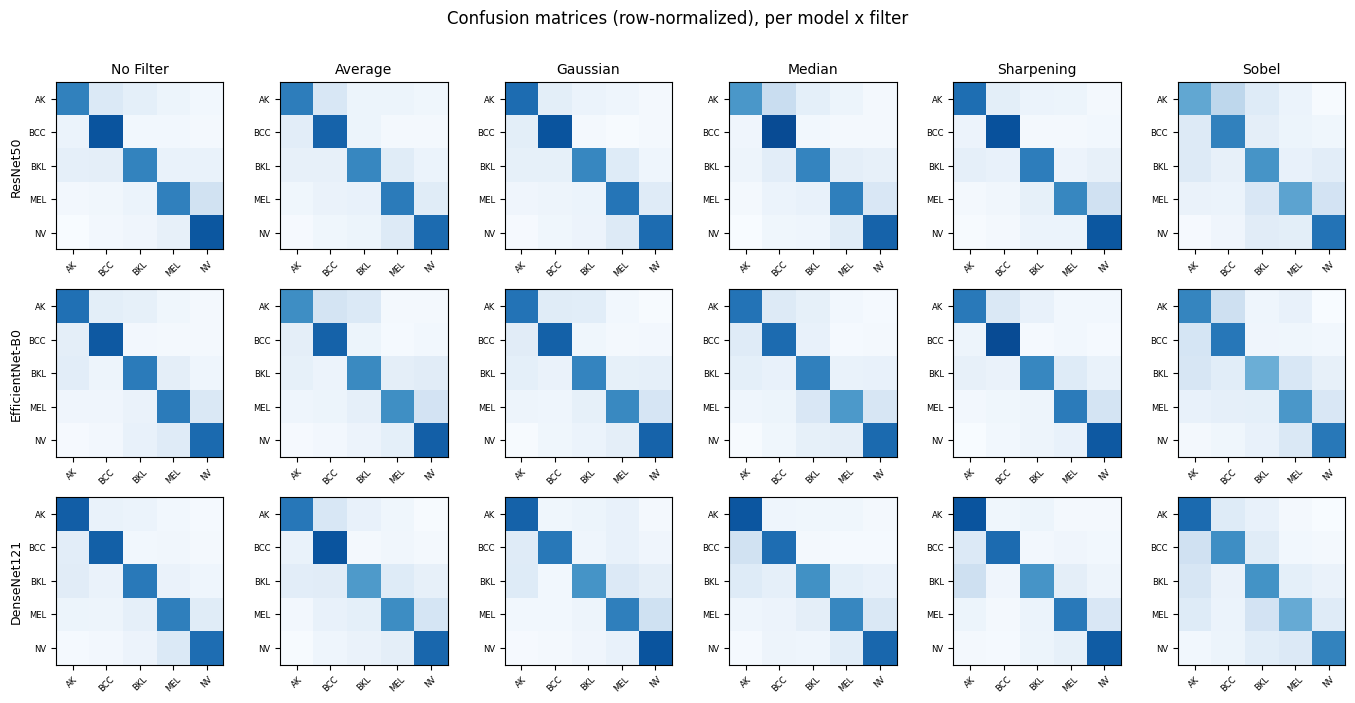

In [17]:
fig, axes = plt.subplots(len(TOP3_MODELS), len(FILTERS), figsize=(2.3 * len(FILTERS), 2.3 * len(TOP3_MODELS)))
for i, name in enumerate(TOP3_MODELS):
    for j, filt in enumerate(FILTERS):
        ax = axes[i, j]
        e = get_extra(name, filt)
        if e is None:
            ax.axis("off"); continue
        cm = np.array(e["confusion_matrix"])
        cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
        ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, fontsize=6, rotation=45)
        ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES, fontsize=6)
        if i == 0:
            ax.set_title(FILTER_DISPLAY[filt], fontsize=10)
        if j == 0:
            ax.set_ylabel(MODEL_DISPLAY[name], fontsize=9)
fig.suptitle("Confusion matrices (row-normalized), per model x filter", y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


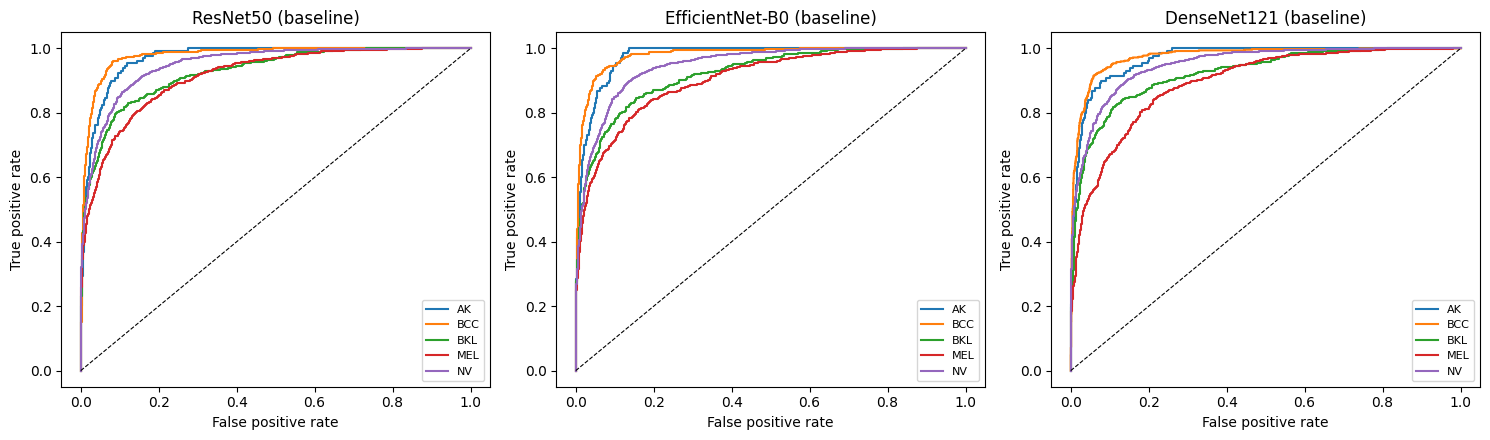

In [18]:
# Representative ROC curves (one-vs-rest, per class) for the unfiltered baseline of each model.
# Full AUC (macro-OVR) for every one of the 18 conditions is already in the §8 table;
# plotting all 18 x 5-class ROC curves here would be excessive for a lab report, so this
# shows the baseline only as a representative illustration.
fig, axes = plt.subplots(1, len(TOP3_MODELS), figsize=(5 * len(TOP3_MODELS), 4.5))
for ax, name in zip(axes, TOP3_MODELS):
    e = get_extra(name, "none")
    if e is None or "y_true" not in e:
        ax.axis("off"); continue
    y_true, y_prob = np.array(e["y_true"]), np.array(e["y_prob"])
    for c, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_prob[:, c])
        ax.plot(fpr, tpr, label=cls)
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_title(f"{MODEL_DISPLAY[name]} (baseline)")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/roc_baseline.png", dpi=120)
plt.show()


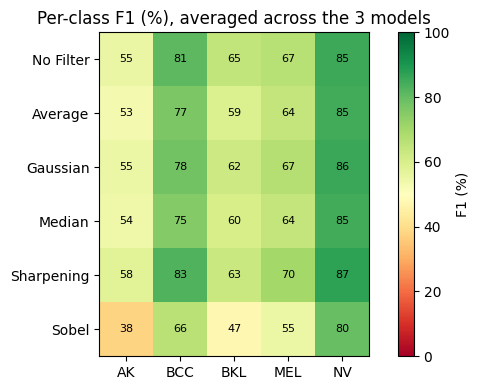

,Model,Filter,Class,Precision (%),Recall (%),F1 (%),Support
0,ResNet50,No Filter,AK,50.00,68.46,57.79,130
1,ResNet50,No Filter,BCC,77.06,86.17,81.36,499
2,ResNet50,No Filter,BKL,64.25,67.68,65.92,393
3,ResNet50,No Filter,MEL,69.39,68.78,69.08,679
4,ResNet50,No Filter,NV,90.55,84.83,87.59,1931
5,ResNet50,Average,AK,42.13,70.00,52.60,130
6,ResNet50,Average,BCC,71.10,80.36,75.45,499
7,ResNet50,Average,BKL,58.39,66.41,62.14,393
8,ResNet50,Average,MEL,60.20,70.84,65.09,679
9,ResNet50,Average,NV,92.65,77.06,84.14,1931


In [19]:
# Per-class metrics, long format: one row per (model, filter, class). Feeds §10's
# "which classes are most affected by filtering" analysis directly.
per_class_rows = []
for name in TOP3_MODELS:
    for filt in FILTERS:
        e = get_extra(name, filt)
        if e is None:
            continue
        pc = e["per_class"]
        for c, cls in enumerate(CLASSES):
            per_class_rows.append({
                "Model": MODEL_DISPLAY[name], "Filter": FILTER_DISPLAY[filt], "Class": cls,
                "Precision (%)": round(pc["precision"][c] * 100, 2),
                "Recall (%)": round(pc["recall"][c] * 100, 2),
                "F1 (%)": round(pc["f1"][c] * 100, 2),
                "Support": pc["support"][c],
            })
per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(f"{RESULTS_DIR}/per_class_results.csv", index=False)

# Heatmap: per-class F1, filter vs. class, averaged across the 3 models
pivot = per_class_df.groupby(["Filter", "Class"])["F1 (%)"].mean().unstack()
pivot = pivot.reindex(index=[FILTER_DISPLAY[f] for f in FILTERS], columns=CLASSES)
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        ax.text(c, r, f"{pivot.values[r, c]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Per-class F1 (%), averaged across the 3 models")
plt.colorbar(im, ax=ax, label="F1 (%)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_class_f1_heatmap.png", dpi=120)
plt.show()
per_class_df.head(12)


## 10. Comparative Analysis

Everything below is structured to directly support the brief's "Questions to Answer" section: baseline-vs-filter deltas per model, which filter moves the needle most, whether the effect direction is consistent across the 3 models, and which classes are hit hardest.


In [20]:
# Delta from each model's own baseline, for every metric and filter.
baseline = results_df[results_df["Filter"] == "No Filter"].set_index("Model")
metric_cols = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)", "Macro-F1 (%)", "Balanced Accuracy (%)", "AUC (%)"]

delta_rows = []
for _, r in results_df[results_df["Filter"] != "No Filter"].iterrows():
    base = baseline.loc[r["Model"]]
    row = {"Model": r["Model"], "Filter": r["Filter"]}
    for m in metric_cols:
        row[f"Delta {m}"] = round(r[m] - base[m], 2)
    delta_rows.append(row)
delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(f"{RESULTS_DIR}/deltas_from_baseline.csv", index=False)
delta_df


,Model,Filter,Delta Accuracy (%),Delta Precision (%),Delta Recall (%),Delta F1-score (%),Delta Macro-F1 (%),Delta Balanced Accuracy (%),Delta AUC (%)
0,ResNet50,Average,-4.63,-5.36,-2.25,-4.47,-4.47,-2.25,-0.82
1,ResNet50,Gaussian,-3.30,-3.50,0.75,-2.28,-2.28,0.75,-0.19
2,ResNet50,Median,-2.15,-0.98,-1.90,-1.40,-1.40,-1.90,-0.21
3,ResNet50,Sharpening,0.47,1.15,1.89,1.31,1.31,1.89,0.63
4,ResNet50,Sobel,-12.06,-14.32,-12.87,-14.64,-14.64,-12.87,-5.64
5,EfficientNet-B0,Average,-0.66,-1.98,-4.80,-2.86,-2.86,-4.80,-1.47
6,EfficientNet-B0,Gaussian,-0.42,-1.18,-2.16,-1.49,-1.49,-2.16,-0.98
7,EfficientNet-B0,Median,-3.42,-4.16,-4.47,-4.61,-4.61,-4.47,-1.55
8,EfficientNet-B0,Sharpening,3.55,4.25,0.63,3.34,3.34,0.63,0.59
9,EfficientNet-B0,Sobel,-9.03,-10.93,-11.54,-11.99,-11.99,-11.54,-5.42


In [21]:
# Which filter produces the greatest change vs. baseline, on average across the 3 models?
filter_impact = delta_df.groupby("Filter")["Delta Accuracy (%)"].agg(lambda s: s.abs().mean()).sort_values(ascending=False)
print("Mean |change in accuracy| vs. baseline, averaged across the 3 models (largest first):")
print(filter_impact.round(2))
print(f"\n-> Largest average effect: {filter_impact.index[0]}")


Mean |change in accuracy| vs. baseline, averaged across the 3 models (largest first):
Filter
Sobel         10.88
Median         2.17
Gaussian       2.15
Sharpening     2.10
Average        2.09
Name: Delta Accuracy (%), dtype: float64

-> Largest average effect: Sobel


In [22]:
# Is the DIRECTION of each filter's effect consistent across the 3 models?
direction = delta_df.pivot(index="Filter", columns="Model", values="Delta Accuracy (%)")
direction = direction.reindex([FILTER_DISPLAY[f] for f in FILTERS[1:]])
sign_agreement = direction.apply(lambda row: (row > 0).all() or (row < 0).all(), axis=1)
print("Delta accuracy (%) by filter x model (sign shows improve/hurt vs. that model's own baseline):")
print(direction.round(2))
print("\nSame direction across all 3 models?")
print(sign_agreement)


Delta accuracy (%) by filter x model (sign shows improve/hurt vs. that model's own baseline):
Model       DenseNet121  EfficientNet-B0  ResNet50
Filter                                            
Average           -0.99            -0.66     -4.63
Gaussian           2.73            -0.42     -3.30
Median            -0.94            -3.42     -2.15
Sharpening         2.29             3.55      0.47
Sobel            -11.56            -9.03    -12.06

Same direction across all 3 models?
Filter
Average        True
Gaussian      False
Median         True
Sharpening     True
Sobel          True
dtype: bool


In [23]:
# Macro-F1 / balanced accuracy specifically (the brief calls these out by name)
print("Delta Macro-F1 (%) and Delta Balanced Accuracy (%) by filter x model:")
print(delta_df.pivot_table(index="Filter", columns="Model", values=["Delta Macro-F1 (%)", "Delta Balanced Accuracy (%)"]).round(2))


Delta Macro-F1 (%) and Delta Balanced Accuracy (%) by filter x model:
           Delta Balanced Accuracy (%)                           \
Model                      DenseNet121 EfficientNet-B0 ResNet50   
Filter                                                            
Average                          -4.28           -4.80    -2.25   
Gaussian                         -2.24           -2.16     0.75   
Median                           -2.36           -4.47    -1.90   
Sharpening                       -0.40            0.63     1.89   
Sobel                           -11.70          -11.54   -12.87   

           Delta Macro-F1 (%)                           
Model             DenseNet121 EfficientNet-B0 ResNet50  
Filter                                                  
Average                 -2.09           -2.86    -4.47  
Gaussian                 0.83           -1.49    -2.28  
Median                  -2.57           -4.61    -1.40  
Sharpening               0.21            3.34     1

In [24]:
# Which classes are most affected by filtering? Spread of F1 across the 6 conditions, per class, averaged over models.
class_spread = per_class_df.groupby(["Model", "Class"])["F1 (%)"].agg(lambda s: s.max() - s.min())
class_spread_avg = class_spread.groupby("Class").mean().sort_values(ascending=False)
print("Average (max-min) F1 swing across the 6 filter conditions, per class (largest first):")
print(class_spread_avg.round(2))
print(f"\n-> Most affected class: {class_spread_avg.index[0]}  |  Least affected: {class_spread_avg.index[-1]}")


Average (max-min) F1 swing across the 6 filter conditions, per class (largest first):
Class
AK     22.72
BKL    17.92
BCC    16.31
MEL    15.26
NV      7.92
Name: F1 (%), dtype: float64

-> Most affected class: AK  |  Least affected: NV


## 11. Summary

| Variable | Contains |
|---|---|
| `results_df` | the 18-row comparison table (§8), also saved to `table_filter_comparison.csv` |
| `per_class_df` | per-class precision/recall/F1 for every (model, filter) (§9), also saved to `per_class_results.csv` |
| `delta_df` | baseline-vs-filter deltas for every metric (§10), also saved to `deltas_from_baseline.csv` |
| `extras` | full per-condition history + confusion matrix + per-class data, also on disk as `extras.json` |
| `RESULTS_DIR` | all of the above, plus the saved figures (`filter_examples.png`, `accuracy_curves.png`, `loss_curves.png`, `confusion_matrices.png`, `roc_baseline.png`, `per_class_f1_heatmap.png`) |

Once this notebook has been run end to end (`results_df` showing 18/18 conditions), send back the executed `.ipynb` (or just `table_filter_comparison.csv` + `deltas_from_baseline.csv` + the figures, if that's easier to attach) and the GitHub README for Lab 02 will be written from these real numbers, answering every question in the brief's "Questions to Answer" section.
